# Task 4: Evaluation

Two things to do here:
1. Compute BLEU on the test set, the testing accuracy metric.
2. Show a few sample images with the generated caption alongside the ground truth.

The test split is the deterministic 80/10/10 with seed 42, done at the image level so no image ends up in more than one split (each image has 5 captions, but they all go to the same split together).

In [12]:
import os, re, csv, pickle, random
from collections import Counter

import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print('device:', device)

device: mps


In [13]:
DATA_DIR = './data'
OUT_DIR = './outputs'
IMAGES_DIR = './flickr8k/Images'

FEATURES_PATH = f'{DATA_DIR}/features.pkl'
VOCAB_PATH = f'{DATA_DIR}/vocab.pkl'
CAPTIONS_TXT_PATH = f'{IMAGES_DIR}/../captions.txt'
MODEL_PATH = f'{OUT_DIR}/model.pt'

PAD_IDX = 0
MAX_CAPTION_LEN = 34
SEED = 42

## Vocabulary class

We need the `Vocabulary` class in scope before loading `vocab.pkl`, since pickle has to be able to reconstruct the object.

In [14]:
class Vocabulary:
    def __init__(self, freq_threshold=5):
        # 4 special tokens: pad / start / end / unknown
        self.itos = {0: '<PAD>', 1: '<START>', 2: '<END>', 3: '<UNK>'}
        self.stoi = {'<PAD>': 0, '<START>': 1, '<END>': 2, '<UNK>': 3}
        self.freq_threshold = freq_threshold  # words rarer than this become <UNK>

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_text(text):
        text = str(text).lower()
        text = text.replace("n't", ' not')
        text = text.replace("'s", ' is')
        text = text.replace("'re", ' are')
        text = text.replace('-', ' ')
        text = re.sub(r'[^a-z\s]', '', text)
        return text.split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_text(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        # wrap in <START>/<END>, unknown words go to <UNK>
        toks = self.tokenizer_text(text)
        return ([self.stoi['<START>']]
                + [self.stoi.get(t, self.stoi['<UNK>']) for t in toks]
                + [self.stoi['<END>']])

## Caption model

Same architecture as the trained checkpoint: dense layer on the image feature, LSTM over the caption tokens, concatenate both into a single vector, then a dense + output layer to predict the next word.

In [15]:
class CaptionModel(nn.Module):
    def __init__(self, vocab_size, feat_dim=4096, emb_dim=256,
                 lstm_units=256, dense_units=256, dropout=0.5, pad_idx=0):
        super().__init__()
        # image branch
        self.img_dropout = nn.Dropout(dropout)
        self.img_dense = nn.Linear(feat_dim, dense_units)
        # caption branch
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.cap_dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(emb_dim, lstm_units, batch_first=True)
        # fusion + output
        self.fusion_dense = nn.Linear(dense_units + lstm_units, dense_units)
        self.output = nn.Linear(dense_units, vocab_size)

    def forward(self, image_feat, caption_seq):
        img = torch.relu(self.img_dense(self.img_dropout(image_feat)))
        emb = self.cap_dropout(self.embedding(caption_seq))
        _, (h_n, _) = self.lstm(emb)
        cap = h_n.squeeze(0)            # final hidden state of the LSTM
        fused = torch.cat([img, cap], dim=1)
        hidden = torch.relu(self.fusion_dense(fused))
        return self.output(hidden)

## Load model, vocab, features

Building the model with `dropout=0.0` since we're only doing inference.

In [16]:
vocab = pickle.load(open(VOCAB_PATH, 'rb'))
image_features = pickle.load(open(FEATURES_PATH, 'rb'))

ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model = CaptionModel(
    vocab_size=ckpt['vocab_size'],
    feat_dim=ckpt['image_feature_dim'],
    emb_dim=ckpt['embedding_dim'],
    lstm_units=ckpt['lstm_units'],
    dense_units=ckpt['dense_units'],
    dropout=0.0,
    pad_idx=ckpt['pad_idx'],
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'{len(vocab)} vocab, {len(image_features)} features, model loaded')

2973 vocab, 8091 features, model loaded


In [17]:
captions_str = {}
with open(CAPTIONS_TXT_PATH) as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        if row[0] in image_features:
            captions_str.setdefault(row[0], []).append(row[1])
print(len(captions_str), 'images with captions')

8091 images with captions


## Test split

Deterministic shuffle with `SEED=42` and split 80/10/10 so the test set is reproducible.

In [18]:
# only keep images that have both a feature vector and captions
ids = sorted(set(image_features) & set(captions_str))
random.Random(SEED).shuffle(ids)

n = len(ids)
test_ids = ids[int(n * 0.9):]   # last 10% after the 80/10 train/val
print(len(test_ids), 'test images')

810 test images


## Greedy caption generator

At each step we feed the current partial sequence + image features into the model, take `argmax` over the vocab, and append that token. Stop when we hit `<END>` or run out of room. Left-padding to keep the input length fixed at `MAX_CAPTION_LEN` since that's the shape the model expects.

In [19]:
@torch.no_grad()   # no gradients at inference
def generate_caption(image_feat, max_len=MAX_CAPTION_LEN):
    start_id = vocab.stoi['<START>']
    end_id = vocab.stoi['<END>']
    seq = [start_id]
    words = []
    # add batch dim of 1
    feat_t = torch.tensor(image_feat, dtype=torch.float32, device=device).unsqueeze(0)

    for _ in range(max_len):
        # left-pad so the input is always max_len long
        padded = ([PAD_IDX] * (max_len - len(seq)) + seq)[-max_len:]
        seq_t = torch.tensor([padded], dtype=torch.long, device=device)
        nxt = int(model(feat_t, seq_t).argmax(1).item())
        if nxt == end_id or nxt == PAD_IDX:
            break
        seq.append(nxt)
        words.append(vocab.itos.get(nxt, '<UNK>'))
    return words

# sanity check on one test image
img_id = test_ids[0]
print('gen:', ' '.join(generate_caption(image_features[img_id])))
print('gt :', captions_str[img_id][0])

gen: a man in a red shirt is sitting on a bench
gt : A person in a red shirt holding a paper bag above a baggage cart .


## Corpus BLEU on the test set

Flickr8k provides 5 reference captions per image, which works well with BLEU since it scores against multiple references. Tokenizing the references with the same `tokenizer_text` used during training so they line up with the generated tokens.

Using `SmoothingFunction().method1`, otherwise corpus BLEU returns 0 whenever a hypothesis is missing a higher-order n-gram, which happens often with short captions.

In [20]:
# corpus_bleu wants:
#   references[i] = list of reference token-lists for image i (5 here)
#   hypotheses[i] = single generated token-list for image i
references = []
hypotheses = []
for img_id in test_ids:
    references.append([Vocabulary.tokenizer_text(c) for c in captions_str[img_id]])
    hyp = generate_caption(image_features[img_id])
    hypotheses.append(hyp if hyp else ['<UNK>'])   # corpus_bleu crashes on empty hyp

# weights pick which n-gram orders contribute to each BLEU-k score
sm = SmoothingFunction().method1
bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=sm)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=sm)
bleu3 = corpus_bleu(references, hypotheses, weights=(1/3, 1/3, 1/3, 0), smoothing_function=sm)
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=sm)

print(f'Test set size: {len(test_ids)}')
print(f'BLEU-1: {bleu1:.4f}')
print(f'BLEU-2: {bleu2:.4f}')
print(f'BLEU-3: {bleu3:.4f}')
print(f'BLEU-4: {bleu4:.4f}')

Test set size: 810
BLEU-1: 0.4827
BLEU-2: 0.3135
BLEU-3: 0.1931
BLEU-4: 0.1217


## Sample captions

Pick 6 random test images and display each one with its ground-truth captions and the one our model generated.

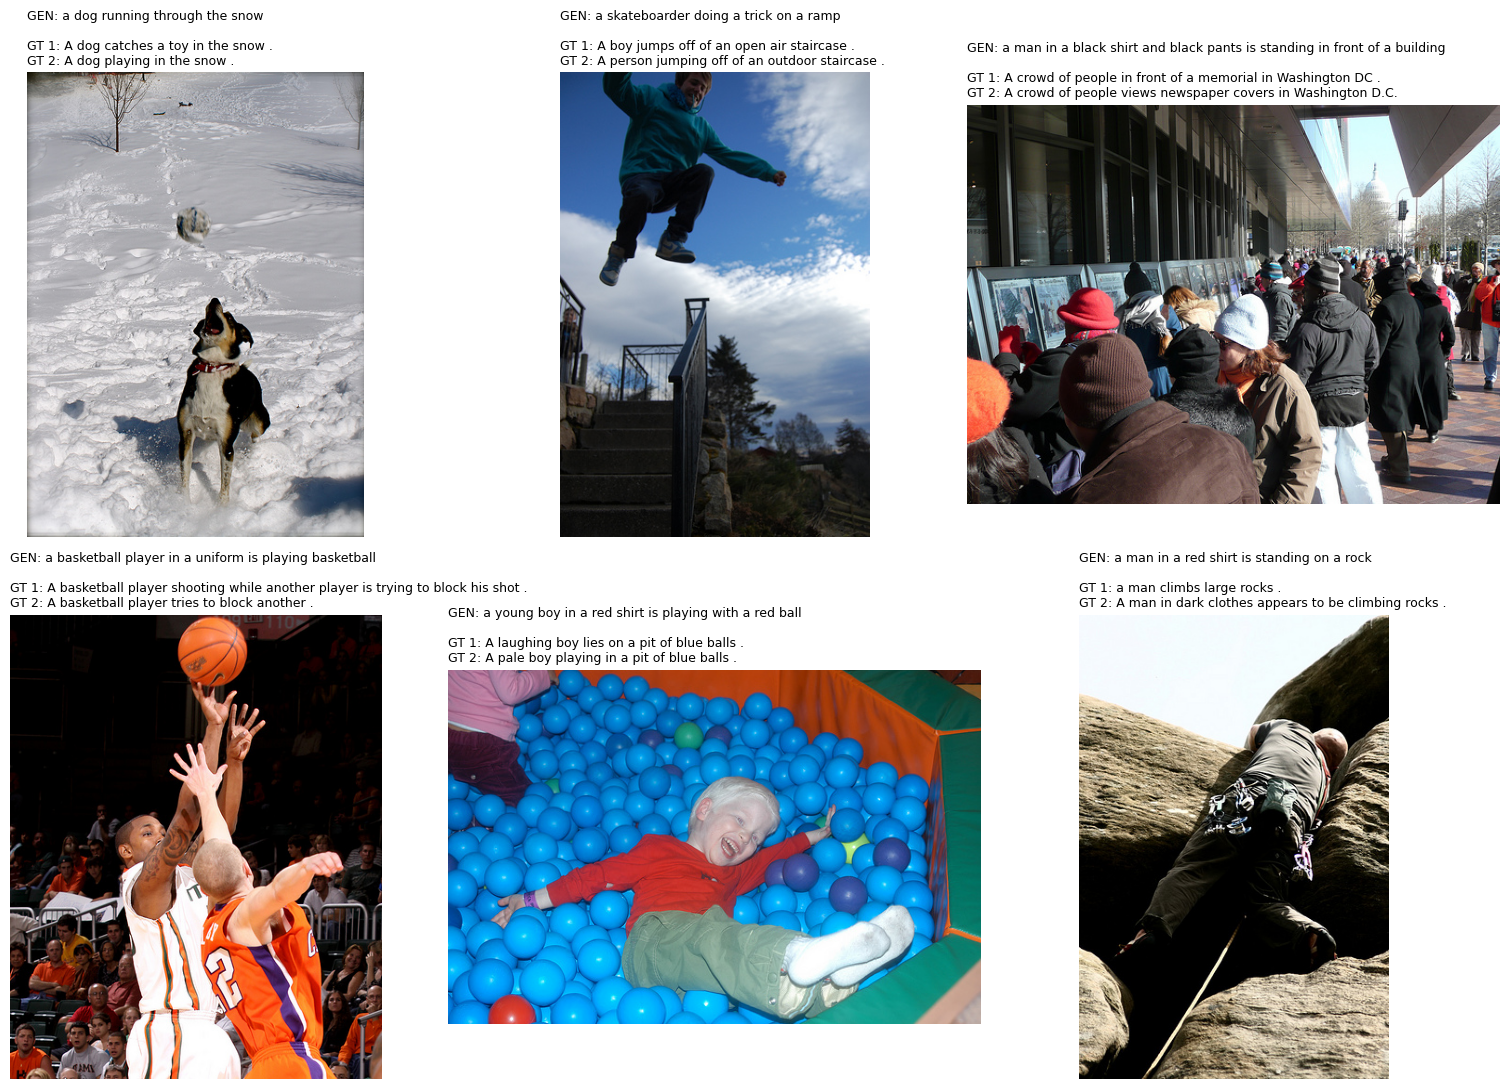

In [21]:
sample_ids = random.Random(123).sample(test_ids, 6)   # different seed from the split

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
for ax, img_id in zip(axes.flat, sample_ids):
    ax.imshow(Image.open(f'{IMAGES_DIR}/{img_id}'))
    ax.axis('off')
    gen = ' '.join(generate_caption(image_features[img_id]))
    refs = captions_str[img_id]
    ax.set_title(f'GEN: {gen}\n\nGT 1: {refs[0]}\nGT 2: {refs[1]}', fontsize=9, loc='left')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/sample_captions.png', dpi=120, bbox_inches='tight')
plt.show()

## Text dump

Plain text version of the 6 sample captions above.

In [22]:
for img_id in sample_ids:
    print('='*70)
    print(f'IMAGE: {img_id}')
    print()
    print(f'  GENERATED: {" ".join(generate_caption(image_features[img_id]))}')
    print()
    print('  REFERENCES:')
    for i, r in enumerate(captions_str[img_id], 1):
        print(f'    {i}. {r}')
    print()

IMAGE: 3392293702_ccb0599857.jpg

  GENERATED: a dog running through the snow

  REFERENCES:
    1. A dog catches a toy in the snow .
    2. A dog playing in the snow .
    3. A dog playing in the snow , ready to catch a toy
    4. A white and black dog is about to catch an object while it stands in a snowy field .
    5. Dog with a red collar running in the snow .

IMAGE: 3348811097_0e09baa26f.jpg

  GENERATED: a skateboarder doing a trick on a ramp

  REFERENCES:
    1. A boy jumps off of an open air staircase .
    2. A person jumping off of an outdoor staircase .
    3. A person jumping step railing .
    4. Boy wearing a blue hoodie jumps over a stair railing .
    5. The young man wearing a blue sweatshirt and blue jeans is hopping over the railing on the fence .

IMAGE: 3215870337_c92a1a1b2f.jpg

  GENERATED: a man in a black shirt and black pants is standing in front of a building

  REFERENCES:
    1. A crowd of people in front of a memorial in Washington DC .
    2. A crowd o